# Comparing the models used for image disease segmentation

## Classic computer vision

`RGB -> Convert to HSV/Lab -> Threshold unhealthy colors -> Morphological Operation -> Connected Components -> Disease Mask`

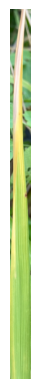

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("../dataset/nitrogen/untitled-10.JPG")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

### Removing the background GrabCut algorithm

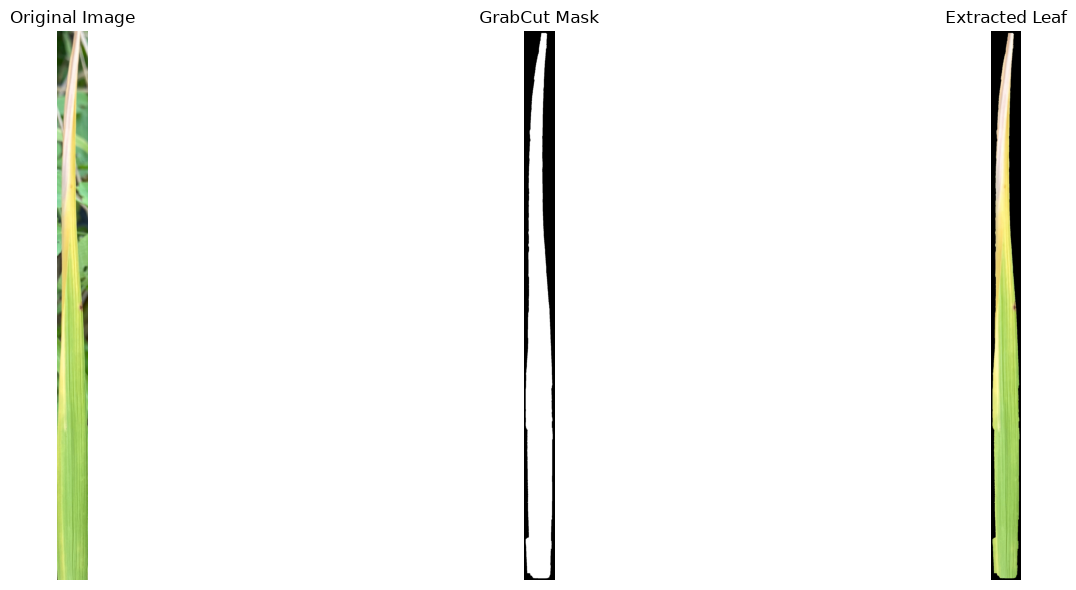

In [3]:
height, width = image.shape[:2]

mask = np.zeros((height, width), np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

margin = 10

rect = (margin, margin, width - 2 * margin, height - 2 * margin)

# running grabcut

cv2.grabCut(
    image,
    mask,
    rect,
    bgdModel,
    fgdModel,
    iterCount=5,
    mode=cv2.GC_INIT_WITH_RECT
)

mask2 = np.where(
    (mask == cv2.GC_BGD) | (mask == cv2.GC_PR_BGD),
    0,
    1,
).astype("uint8")

leaf = image_rgb * mask2[:,:,np.newaxis]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mask2, cmap="gray")
ax[1].set_title("GrabCut Mask")
ax[1].axis("off")

ax[2].imshow(leaf)
ax[2].set_title("Extracted Leaf")
ax[2].axis("off")

plt.tight_layout()
plt.show()




GrabCut assumes the object is completely inside the rectangle. If your paddy leaf touches the image border or there are multiple leaves in the frame, it may incorrectly classify parts of the leaf as background.

### Loading the image

### Splitting the image color

Text(0.5, 1.0, 'Red')

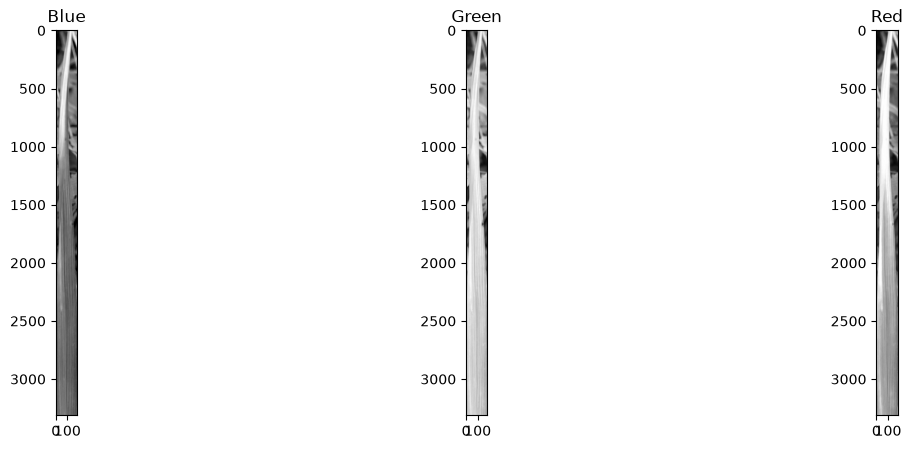

In [4]:
B, G, R = cv2.split(image)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(B, cmap="gray")
ax[0].set_title("Blue")

ax[1].imshow(G, cmap="gray")
ax[1].set_title("Green")

ax[2].imshow(R, cmap="gray")
ax[2].set_title("Red")

### Convert to other spaces

In [5]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Red
  ↑
330°      30°

Purple      Yellow

240°      60°

Blue      Green

120°

In [6]:
import numpy as np

lower_green = np.array([35,40,40])
upper_green = np.array([85,255,255])

In [7]:
mask = cv2.inRange(hsv, lower_green, upper_green)

Text(0.5, 1.0, 'Leaf Mask')

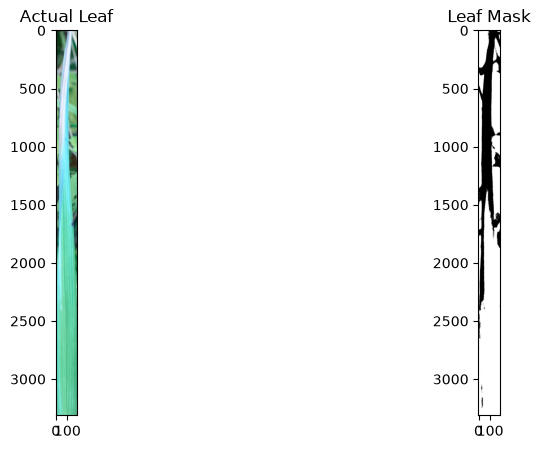

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image)
ax[0].set_title("Actual Leaf")

ax[1].imshow(mask, cmap="grey")
ax[1].set_title("Leaf Mask")